# 03 · Held-out test: TabPFN-3.5 vs NESO, 2025–2026

Same model as `02`, scored once on 2025-01-01 → 2026-09-15 under the protocol frozen in `docs/method.md`.
Monthly runs refit on every hour settled a day before issue; `frozen` runs keep the 2024 context throughout.
`blend` is the fixed 50/50 WINDFOR/power-curve benchmark (power curve fitted on Mar–Jul 2024), the bar for `tabpfn+windfor`.

In [1]:
import pandas as pd
from windpfn import baselines, dataset, figures, model

d = baselines.add(dataset.build("2024-03-16", "2026-09-15").set_index("valid_time"))
X = model.features(d)
F = {"tabpfn": X, "tabpfn+windfor": X.join(d.windfor)}

In [2]:
start = "2025-01-01"
runs = {k + ("" if refit else " frozen"): model.backtest(x, d, start, refit=refit) for k, x in F.items() for refit in (True, False)}
test = d[start:].assign(**{k: r.q50 for k, r in runs.items()})
err = test[["windfor", "blend", *runs]].sub(test.y, axis=0)
model.score(err)

,MAE,RMSE,bias,ΔMAE,lo,hi
windfor,1022.0,1349.0,90.0,0.0,0.0,0.0
blend,969.0,1277.0,-218.0,-53.0,-85.0,-22.0
tabpfn,1026.0,1400.0,-132.0,5.0,-45.0,53.0
tabpfn frozen,1067.0,1445.0,-334.0,45.0,-7.0,98.0
tabpfn+windfor,912.0,1252.0,89.0,-109.0,-146.0,-72.0
tabpfn+windfor frozen,922.0,1257.0,141.0,-100.0,-136.0,-63.0


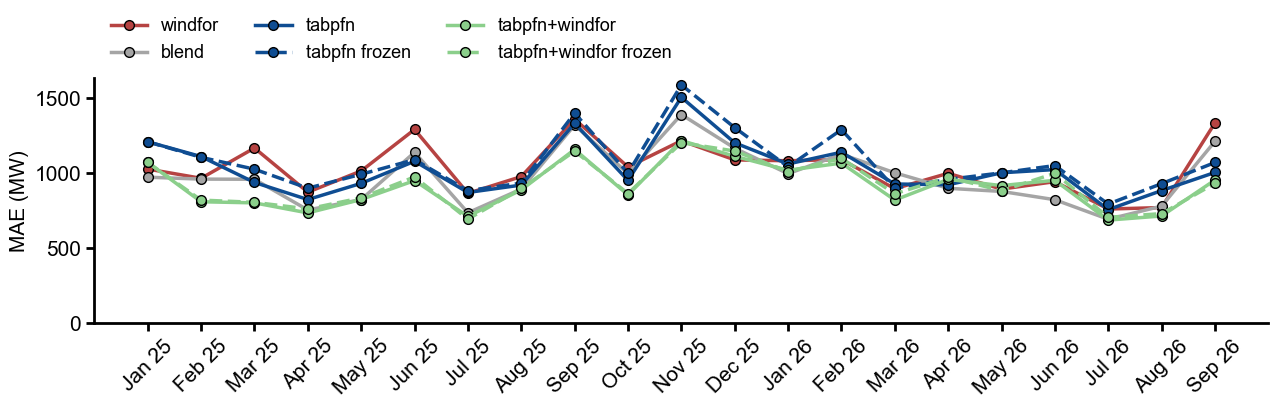

In [3]:
figures.monthly(err);

In [4]:
err.abs().groupby(pd.cut(test.lead_h, [15, 21, 27, 33, 40]), observed=True).mean().round(0)

,windfor,blend,tabpfn,tabpfn frozen,tabpfn+windfor,tabpfn+windfor frozen
lead_h,,,,,,
"(15, 21]",879.0,845.0,875.0,924.0,775.0,796.0
"(21, 27]",1005.0,929.0,969.0,993.0,881.0,889.0
"(27, 33]",1062.0,996.0,1065.0,1119.0,956.0,962.0
"(33, 40]",1125.0,1089.0,1176.0,1212.0,1021.0,1026.0


In [5]:
q = pd.concat({f"{k}|{c}": r[c] for k, r in runs.items() for c in r}, axis=1)
test[["y", "windfor", "blend", "lead_h", "cap"]].join(q).to_parquet("data/test_forecasts.parquet")